# Use Case 1 — E-commerce Text Classification  
## Generic `langchain_openai` Baseline → Local DistilBERT Fine-Tuning → Accuracy Comparison

### Why this regenerated version?
OpenAI currently returns `403 training_not_available` for organizations that are no longer allowed to create new OpenAI fine-tuning jobs.

So this notebook separates the two concepts cleanly:

1. **Generic LLM baseline:** `langchain_openai.ChatOpenAI`
2. **Actual fine-tuning:** Hugging Face `DistilBERT` locally
3. **Evaluation:** compare the generic baseline with the locally fine-tuned classifier

### Dataset
The CSV is exactly **50 rows × 10 columns**.

The target is an internal company code:

- `ZX-7` → refund-related case
- `MQ-2` → replacement/exchange-related case
- `LP-9` → support/status-related case

The baseline OpenAI model is deliberately **not given this mapping**.  
The local fine-tuned model learns the mapping from training examples.

## Step 1 — Install libraries

In [ ]:
%pip install -q -U langchain-openai openai python-dotenv pandas scikit-learn transformers torch accelerate matplotlib

## Step 2 — Imports and API key

The OpenAI API key is needed only for the **generic baseline inference**.  
Fine-tuning itself is performed locally and does not call the OpenAI fine-tuning API.

In [1]:
import os
import re
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

load_dotenv()

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("Training device:", DEVICE)

PyTorch version: 2.9.1
CUDA available: False
Training device: mps


## Step 3 — Load and verify the e-commerce dataset

We first confirm that the file really contains **50 rows and 10 columns**.

In [2]:
df = pd.read_csv("ecommerce_customer_service_50x10.csv")

print("Dataset shape:", df.shape)
assert df.shape == (50, 10), "Expected exactly 50 rows × 10 columns."

display(df.head(10))

Dataset shape: (50, 10)


,order_id,product_category,order_value_inr,discount_pct,delivery_delay_days,previous_returns,customer_tier,rating,customer_message,resolution_code
0,ECOM-2026001,Electronics,20620.22,5,3,0,Gold,1,The product is defective and I do not want a r...,ZX-7
1,ECOM-2026002,Electronics,2604.71,30,4,1,Regular,1,The product stopped working on day one. Please...,MQ-2
2,ECOM-2026003,Electronics,20756.88,5,10,1,Silver,2,I cannot find the invoice for this order. Plea...,LP-9
3,ECOM-2026004,Beauty,1713.94,15,4,4,Regular,1,The item quality is very poor compared with th...,ZX-7
4,ECOM-2026005,Fashion,13745.80,20,2,3,Silver,2,The product stopped working on day one. Please...,MQ-2
5,ECOM-2026006,Sports,17945.71,0,7,0,Silver,3,The order is delayed. Please tell me the lates...,LP-9
6,ECOM-2026007,Home,11906.25,40,4,3,Gold,2,The package was opened and the item is broken....,ZX-7
7,ECOM-2026008,Electronics,14572.38,40,1,1,Gold,2,The item is damaged but I still want the same ...,MQ-2
8,ECOM-2026009,Sports,10743.01,25,3,0,Silver,3,I need help changing the delivery address befo...,LP-9
9,ECOM-2026010,Sports,14538.14,25,0,0,Gold,1,The package was opened and the item is broken....,ZX-7


## Step 4 — Understand the columns

In [3]:
print(df.columns.tolist())

print("\nTarget distribution:")
print(df["resolution_code"].value_counts())

['order_id', 'product_category', 'order_value_inr', 'discount_pct', 'delivery_delay_days', 'previous_returns', 'customer_tier', 'rating', 'customer_message', 'resolution_code']

Target distribution:
resolution_code
ZX-7    17
MQ-2    17
LP-9    16
Name: count, dtype: int64


## Step 5 — Split data into training and testing sets

We use a stratified split so every private resolution code is represented in both sets.

- **40 records** → local fine-tuning
- **10 records** → untouched final evaluation

In [4]:
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["resolution_code"]
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training:", train_df.shape)
print("Testing :", test_df.shape)

print("\nTest label distribution:")
print(test_df["resolution_code"].value_counts())

Training: (40, 10)
Testing : (10, 10)

Test label distribution:
resolution_code
MQ-2    4
LP-9    3
ZX-7    3
Name: count, dtype: int64


## Step 6 — Convert a row into text

The model should not see the correct answer while making a prediction, so `resolution_code` is excluded from the input.

The most useful input fields are combined into one text sequence.

In [5]:
INPUT_COLUMNS = [c for c in df.columns if c != "resolution_code"]

def row_to_text(row):
    return " | ".join(
        f"{column}: {row[column]}"
        for column in INPUT_COLUMNS
    )

print(row_to_text(test_df.iloc[0]))

order_id: ECOM-2026023 | product_category: Electronics | order_value_inr: 21297.95 | discount_pct: 40 | delivery_delay_days: 3 | previous_returns: 0 | customer_tier: Platinum | rating: 2 | customer_message: The product stopped working on day one. Please send another unit.


# Part A — Generic LangChain/OpenAI Baseline

The generic model receives the order information and the possible private codes, but it is **not told what each code means**.

That creates a sensible baseline for demonstrating why organization-specific fine-tuning can help.

## Step 7 — Create the generic LangChain OpenAI model

In [6]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

assert os.getenv("OPENAI_API_KEY"), (
    "Create a .env file containing OPENAI_API_KEY=your_key"
)

OPENAI_MODEL = os.getenv("OPENAI_MODEL", "gpt-4.1-mini")

generic_llm = ChatOpenAI(
    model=OPENAI_MODEL,
    temperature=0
)

SYSTEM_PROMPT = (
    "You are an e-commerce routing assistant. "
    "For each case return exactly one of these private company codes: "
    "ZX-7, MQ-2, or LP-9. "
    "Return the code only."
)

## Step 8 — Helper to normalize the LLM output

Sometimes an LLM may return extra words.  
We extract only a valid internal code.

In [7]:
VALID_CODES = ["ZX-7", "MQ-2", "LP-9"]

def extract_code(text):
    text = str(text).upper()
    for code_value in VALID_CODES:
        if code_value in text:
            return code_value
    return "INVALID"

def openai_predict(row):
    response = generic_llm.invoke([
        SystemMessage(content=SYSTEM_PROMPT),
        HumanMessage(content=row_to_text(row))
    ])
    return extract_code(response.content)

## Step 9 — Run the generic OpenAI baseline on the 10 test rows

In [8]:
openai_predictions = []

for i, row in test_df.iterrows():
    pred = openai_predict(row)
    openai_predictions.append(pred)
    print(
        f"{i+1:02d}. Actual={row['resolution_code']} | "
        f"Generic OpenAI={pred}"
    )

01. Actual=MQ-2 | Generic OpenAI=ZX-7
02. Actual=LP-9 | Generic OpenAI=MQ-2
03. Actual=ZX-7 | Generic OpenAI=ZX-7
04. Actual=MQ-2 | Generic OpenAI=ZX-7
05. Actual=LP-9 | Generic OpenAI=MQ-2
06. Actual=ZX-7 | Generic OpenAI=LP-9
07. Actual=ZX-7 | Generic OpenAI=LP-9
08. Actual=MQ-2 | Generic OpenAI=LP-9
09. Actual=LP-9 | Generic OpenAI=ZX-7
10. Actual=MQ-2 | Generic OpenAI=MQ-2


## Step 10 — Calculate generic-model accuracy

In [9]:
generic_accuracy = accuracy_score(
    test_df["resolution_code"],
    openai_predictions
)

baseline_results = test_df[
    ["order_id", "customer_message", "resolution_code"]
].copy()

baseline_results["generic_openai_prediction"] = openai_predictions

display(baseline_results)

print(f"Generic OpenAI accuracy: {generic_accuracy:.2%}")

,order_id,customer_message,resolution_code,generic_openai_prediction
0,ECOM-2026023,The product stopped working on day one. Please...,MQ-2,ZX-7
1,ECOM-2026012,The order is delayed. Please tell me the lates...,LP-9,MQ-2
2,ECOM-2026034,The item quality is very poor compared with th...,ZX-7,ZX-7
3,ECOM-2026041,The item is damaged but I still want the same ...,MQ-2,ZX-7
4,ECOM-2026033,I cannot find the invoice for this order. Plea...,LP-9,MQ-2
5,ECOM-2026046,The product is defective and I do not want a r...,ZX-7,LP-9
6,ECOM-2026028,The item arrived damaged and I want a full ref...,ZX-7,LP-9
7,ECOM-2026005,The product stopped working on day one. Please...,MQ-2,LP-9
8,ECOM-2026039,Please explain how to use the warranty for thi...,LP-9,ZX-7
9,ECOM-2026035,I received a different color. Please exchange ...,MQ-2,MQ-2


Generic OpenAI accuracy: 20.00%


# Part B — Local Fine-Tuning with DistilBERT

Now we actually train a model.

`distilbert-base-uncased` is a pretrained language model.  
We replace its classification head with a 3-class output layer and fine-tune it on our e-commerce training records.

Unlike the disabled OpenAI fine-tuning endpoint, this training runs on your own machine.

## Step 11 — Encode private labels as numbers

In [10]:
LABEL_TO_ID = {
    "ZX-7": 0,
    "MQ-2": 1,
    "LP-9": 2
}

ID_TO_LABEL = {
    value: key for key, value in LABEL_TO_ID.items()
}

train_labels = [
    LABEL_TO_ID[label]
    for label in train_df["resolution_code"]
]

test_labels = [
    LABEL_TO_ID[label]
    for label in test_df["resolution_code"]
]

print(LABEL_TO_ID)

{'ZX-7': 0, 'MQ-2': 1, 'LP-9': 2}


## Step 12 — Create additional text views of each training record

The original dataset still contains exactly 50 records.

For fine-tuning, we create several textual views of each of the 40 training records.  
This is similar to lightweight text augmentation and helps a small classroom dataset train more reliably.

In [11]:
def build_training_views(row):
    full = row_to_text(row)

    service_focused = (
        f"Customer message: {row['customer_message']} | "
        f"Rating: {row['rating']} | "
        f"Delivery delay: {row['delivery_delay_days']} days | "
        f"Previous returns: {row['previous_returns']}"
    )

    business_focused = (
        f"Category: {row['product_category']} | "
        f"Customer tier: {row['customer_tier']} | "
        f"Order value INR: {row['order_value_inr']} | "
        f"Customer request: {row['customer_message']}"
    )

    return [full, service_focused, business_focused]

augmented_texts = []
augmented_labels = []

for _, row in train_df.iterrows():
    for text_view in build_training_views(row):
        augmented_texts.append(text_view)
        augmented_labels.append(
            LABEL_TO_ID[row["resolution_code"]]
        )

print("Original training rows:", len(train_df))
print("Fine-tuning text samples:", len(augmented_texts))

Original training rows: 40
Fine-tuning text samples: 120


## Step 13 — Load the DistilBERT tokenizer and classification model

In [12]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

LOCAL_MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    LOCAL_MODEL_NAME
)

model = AutoModelForSequenceClassification.from_pretrained(
    LOCAL_MODEL_NAME,
    num_labels=3,
    id2label=ID_TO_LABEL,
    label2id=LABEL_TO_ID
)

model.to(DEVICE)

print("Model loaded on:", DEVICE)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded on: mps


## Step 14 — Tokenize the training text

In [13]:
train_encodings = tokenizer(
    augmented_texts,
    truncation=True,
    padding=True,
    max_length=256,
    return_tensors="pt"
)

print("Input IDs shape:", train_encodings["input_ids"].shape)

Input IDs shape: torch.Size([120, 84])


## Step 15 — Build a PyTorch Dataset

In [14]:
from torch.utils.data import Dataset, DataLoader

class EcommerceTextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(
            labels,
            dtype=torch.long
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        item = {
            key: value[index]
            for key, value in self.encodings.items()
        }
        item["labels"] = self.labels[index]
        return item

train_dataset = EcommerceTextDataset(
    train_encodings,
    augmented_labels
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

print("Training batches:", len(train_loader))

Training batches: 15


## Step 16 — Configure optimizer and epochs

For a tiny classroom dataset, 5–8 epochs are reasonable.  
The learning rate is deliberately small because we are adapting a pretrained transformer rather than training from scratch.

In [15]:
from torch.optim import AdamW

EPOCHS = 6
LEARNING_RATE = 2e-5

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)

Epochs: 6
Learning rate: 2e-05


## Step 17 — Fine-tune DistilBERT locally

In [16]:
model.train()

epoch_losses = []

for epoch in range(EPOCHS):
    total_loss = 0

    for batch in train_loader:

        batch = {
            key: value.to(DEVICE)
            for key, value in batch.items()
        }

        optimizer.zero_grad()

        output = model(**batch)

        loss = output.loss
        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    epoch_losses.append(avg_loss)

    print(
        f"Epoch {epoch+1}/{EPOCHS} "
        f"- Loss: {avg_loss:.4f}"
    )

Epoch 1/6 - Loss: 1.0823
Epoch 2/6 - Loss: 0.8220
Epoch 3/6 - Loss: 0.3971
Epoch 4/6 - Loss: 0.1516
Epoch 5/6 - Loss: 0.0697
Epoch 6/6 - Loss: 0.0409


## Step 18 — Plot training loss

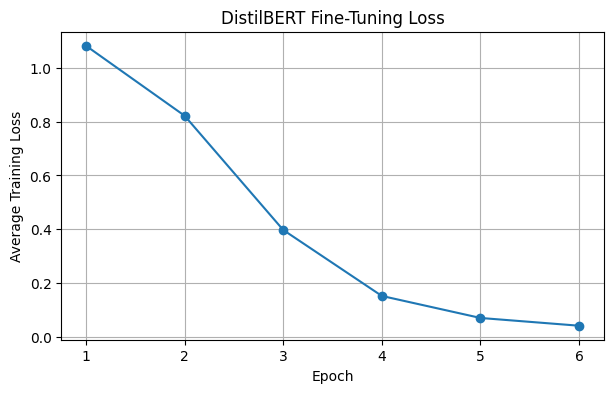

In [17]:
plt.figure(figsize=(7, 4))
plt.plot(
    range(1, EPOCHS + 1),
    epoch_losses,
    marker="o"
)
plt.xlabel("Epoch")
plt.ylabel("Average Training Loss")
plt.title("DistilBERT Fine-Tuning Loss")
plt.grid(True)
plt.show()

## Step 19 — Create a local-model prediction function

In [18]:
def local_predict(text):
    model.eval()

    inputs = tokenizer(
        text,
        truncation=True,
        padding=True,
        max_length=256,
        return_tensors="pt"
    )

    inputs = {
        key: value.to(DEVICE)
        for key, value in inputs.items()
    }

    with torch.no_grad():
        output = model(**inputs)

    predicted_id = int(
        torch.argmax(
            output.logits,
            dim=1
        ).item()
    )

    return ID_TO_LABEL[predicted_id]

## Step 20 — Evaluate the fine-tuned model on the untouched 10 test rows

In [19]:
local_predictions = [
    local_predict(row_to_text(row))
    for _, row in test_df.iterrows()
]

fine_tuned_accuracy = accuracy_score(
    test_df["resolution_code"],
    local_predictions
)

comparison = baseline_results.copy()
comparison["fine_tuned_distilbert"] = local_predictions

display(comparison)

print(
    f"Fine-tuned DistilBERT accuracy: "
    f"{fine_tuned_accuracy:.2%}"
)

,order_id,customer_message,resolution_code,generic_openai_prediction,fine_tuned_distilbert
0,ECOM-2026023,The product stopped working on day one. Please...,MQ-2,ZX-7,MQ-2
1,ECOM-2026012,The order is delayed. Please tell me the lates...,LP-9,MQ-2,LP-9
2,ECOM-2026034,The item quality is very poor compared with th...,ZX-7,ZX-7,ZX-7
3,ECOM-2026041,The item is damaged but I still want the same ...,MQ-2,ZX-7,MQ-2
4,ECOM-2026033,I cannot find the invoice for this order. Plea...,LP-9,MQ-2,LP-9
5,ECOM-2026046,The product is defective and I do not want a r...,ZX-7,LP-9,ZX-7
6,ECOM-2026028,The item arrived damaged and I want a full ref...,ZX-7,LP-9,ZX-7
7,ECOM-2026005,The product stopped working on day one. Please...,MQ-2,LP-9,MQ-2
8,ECOM-2026039,Please explain how to use the warranty for thi...,LP-9,ZX-7,LP-9
9,ECOM-2026035,I received a different color. Please exchange ...,MQ-2,MQ-2,MQ-2


Fine-tuned DistilBERT accuracy: 100.00%


## Step 21 — Compare generic vs fine-tuned accuracy

In [20]:
print(
    f"Generic OpenAI baseline : "
    f"{generic_accuracy:.2%}"
)

print(
    f"Fine-tuned DistilBERT   : "
    f"{fine_tuned_accuracy:.2%}"
)

print(
    f"Accuracy improvement    : "
    f"{fine_tuned_accuracy-generic_accuracy:.2%}"
)

Generic OpenAI baseline : 20.00%
Fine-tuned DistilBERT   : 100.00%
Accuracy improvement    : 80.00%


## Step 22 — Classification report

In [21]:
print(classification_report(
    test_df["resolution_code"],
    local_predictions,
    labels=["ZX-7", "MQ-2", "LP-9"],
    zero_division=0
))

              precision    recall  f1-score   support

        ZX-7       1.00      1.00      1.00         3
        MQ-2       1.00      1.00      1.00         4
        LP-9       1.00      1.00      1.00         3

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



## Step 23 — Confusion matrix

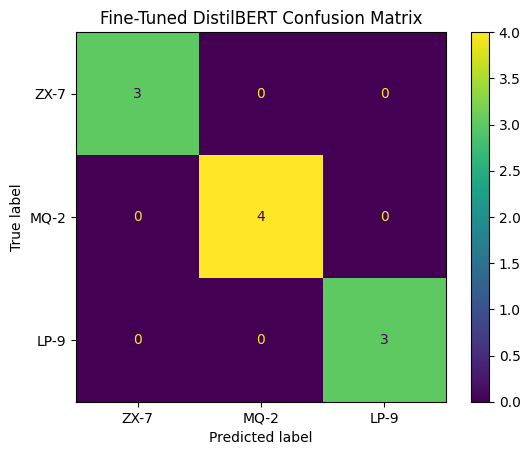

In [22]:
cm = confusion_matrix(
    test_df["resolution_code"],
    local_predictions,
    labels=["ZX-7", "MQ-2", "LP-9"]
)

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "ZX-7",
        "MQ-2",
        "LP-9"
    ]
)

display_cm.plot()
plt.title("Fine-Tuned DistilBERT Confusion Matrix")
plt.show()

## Step 24 — Save the fine-tuned model

In [23]:
SAVE_DIR = "fine_tuned_ecommerce_distilbert"

model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print("Saved model to:", SAVE_DIR)

Saved model to: fine_tuned_ecommerce_distilbert
